In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from collections import Counter

In [2]:
# Import data 
data_path_news = Path("dataset") / "news.tsv"
data_path_user_interaction = Path("dataset") / "behaviors.tsv"
data_path_news_embeddings = Path("dataset") / "article_embeddings.npy"

news_articles = pd.read_csv(
    data_path_news,
    sep="\t",
    header=None
)
news_articles.columns = ['News_ID', 
                         'Category', 
                         'Subcategory',
                         'Title',
                         'Abstract',
                         'URL',
                         'Title Entities',
                         'Abstract Entities']

users_interaction = pd.read_csv(
    data_path_user_interaction,
    sep="\t",
    header=None
)
users_interaction.columns = ['No.',
                            'User_ID',
                            'Time_Stamp',
                            'History',
                            'Impression']


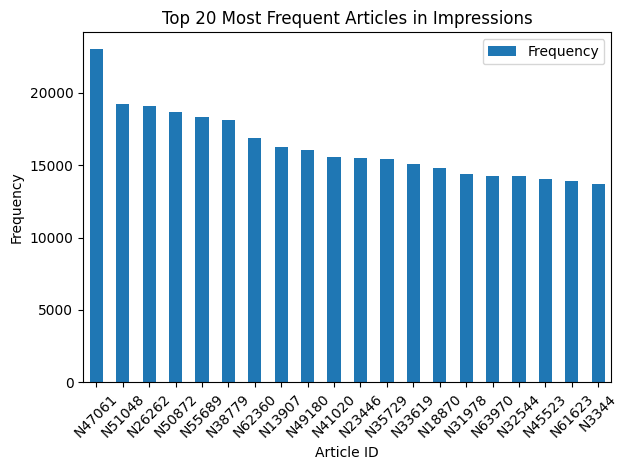

Median frequency of article appearances: 7.0


In [3]:
# Split impressions into lists
users_interaction["Impression_List"] = users_interaction["Impression"].str.split()

# Extract article IDs
users_interaction["Article_IDs"] = users_interaction["Impression_List"].apply(
    lambda x: [item.split("-")[0] for item in x] if isinstance(x, list) else []
)

# Flatten all article IDs
all_article_ids = [
    article
    for sublist in users_interaction["Article_IDs"]
    for article in sublist
]

# Count frequency
article_distribution = Counter(all_article_ids)

# Convert to DataFrame (optional)
article_dist_df = pd.DataFrame.from_dict(article_distribution, orient='index', columns=['Frequency'])
article_dist_df = article_dist_df.sort_values(by='Frequency', ascending=False)

import matplotlib.pyplot as plt

# Top 20 most frequent articles
top_n = 20
article_dist_df.head(top_n).plot(kind='bar')

plt.title("Top 20 Most Frequent Articles in Impressions")
plt.ylabel("Frequency")
plt.xlabel("Article ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

frequencies = np.array(list(article_distribution.values()))

median_freq = np.median(frequencies)

print("Median frequency of article appearances:", median_freq)

In [4]:
# Count number of articles per impression
users_interaction["Num_Articles"] = users_interaction["Article_IDs"].apply(len)

# Average
avg_articles = users_interaction["Num_Articles"].mean()

print("Average number of articles per impression:", avg_articles)
print("Average Probability of Random Chance (%):", 100 / avg_articles)

Average number of articles per impression: 37.22768770107986
Average Probability of Random Chance (%): 2.686172743334239


In [5]:
# Unique arms
print(len(np.unique(news_articles['News_ID'])))
print(len(np.unique(news_articles['Category'])))

51282
17


         Category  Click_Count
0            news        46505
1          sports        19867
2       lifestyle        16768
3         finance        13662
4           music        11629
5              tv        10386
6   entertainment         6592
7          health         6478
8    foodanddrink         6279
9          travel         5052
10          autos         4610
11        weather         3633
12         movies         2791
13          video         2709
14           kids            3
15   northamerica            1


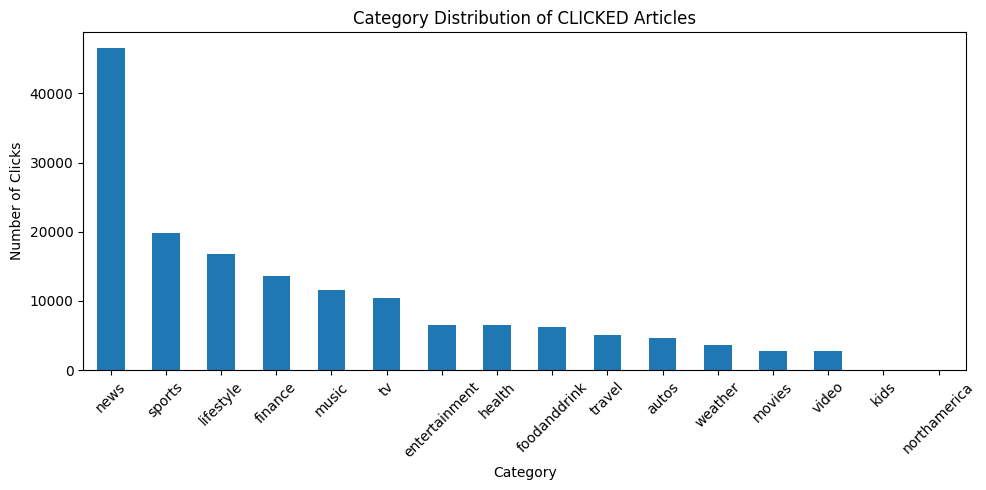

      index Clicked_Category Clicked_ID  Click_Count
0       101            autos     N38215          304
1       112            autos     N41220          231
2       204            autos      N7618          227
3        18            autos     N16844          170
4        26            autos     N19318          162
...     ...              ...        ...          ...
6353   6344          weather      N6617            1
6354   6350          weather      N8470            1
6355   6351          weather      N8494            1
6356   6353          weather       N924            1
6357   6356          weather      N9776            1

[6358 rows x 4 columns]
   Clicked_Category  Unique_Articles
0              news             1886
1            sports             1555
2           finance              436
3         lifestyle              396
4      foodanddrink              345
5            health              312
6            travel              291
7           weather              240
8     

In [ ]:
# Extract clicked article ID from each impression
users_interaction["Clicked_ID"] = users_interaction["Impression_List"].apply(
    lambda x: next((item.split("-")[0] for item in x if item.endswith("-1")), None)
)

news_to_category = dict(zip(news_articles["News_ID"], news_articles["Category"]))

users_interaction["Clicked_Category"] = users_interaction["Clicked_ID"].map(news_to_category)

clicked_cat_df = (
    users_interaction["Clicked_Category"]
    .value_counts()
    .reset_index()
)

clicked_cat_df.columns = ["Category", "Click_Count"]

print(clicked_cat_df)

clicked_cat_df.plot(
    x="Category",
    y="Click_Count",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.title("Category Distribution of CLICKED Articles")
plt.ylabel("Number of Clicks")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

article_clicks = (
    users_interaction
    .groupby(["Clicked_Category", "Clicked_ID"])
    .size()
    .reset_index(name="Click_Count") 
    .sort_values(["Clicked_Category", "Click_Count"], ascending=[True, False])
    .reset_index(drop=True)
)

print(article_clicks)

unique_articles_per_cat = (
    article_clicks
    .groupby("Clicked_Category")["Clicked_ID"]
    .nunique()
    .reset_index(name="Unique_Articles")
    .sort_values("Unique_Articles", ascending=False)
    .reset_index(drop=True)

)
print(unique_articles_per_cat.to_string())

In [7]:
def get_history_count(history):
    if pd.isna(history) or history == "":
        return 0
    return len(history.split())
users_interaction["history_count"] = users_interaction["History"].apply(get_history_count)
num_users = len(users_interaction)
num_cold = (users_interaction["history_count"] == 0).sum()
print("Cold-start users:", num_cold)
print("Percentage:", num_cold / num_users * 100, "%")

Cold-start users: 3238
Percentage: 2.062880259930558 %
